# 音频表示与 Tokenization 方式轻量化体验指南

本文档系统介绍音频的不同表示方式和 Tokenization 方法，每种方式包含：概念介绍、代码示例、预期输出。

---

## 第一部分：音频表示方式

### 1. 原始波形表示 (Raw Waveform)

波形形状: (44100,)
采样率: 22050 Hz
时长: 2.00 秒
振幅范围: [-0.6848, 0.6316]


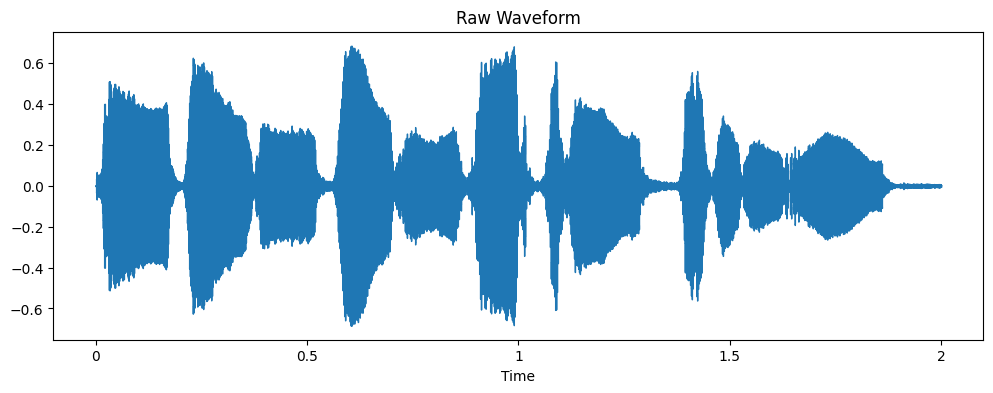

In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

y, sr = librosa.load(librosa.ex('trumpet'), duration=2.0)

print(f"波形形状: {y.shape}")
print(f"采样率: {sr} Hz")
print(f"时长: {len(y)/sr:.2f} 秒")
print(f"振幅范围: [{y.min():.4f}, {y.max():.4f}]")

plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr)
plt.title('Raw Waveform')
plt.savefig('waveform.png', dpi=100)
plt.show()

### 2. 频谱表示 (Spectrogram)

**概念**：时频域表示，展示不同频率成分在不同时刻的能量分布。

STFT 矩阵形状: (1025, 87)
频率 bins: 1025
时间帧数: 87


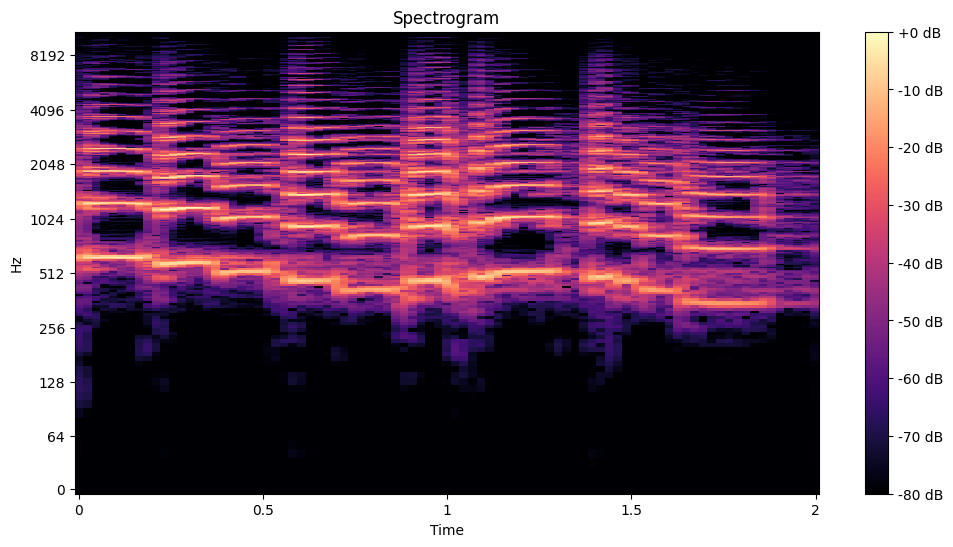

In [2]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

y, sr = librosa.load(librosa.ex('trumpet'), duration=2.0)

D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

print(f"STFT 矩阵形状: {D.shape}")
print(f"频率 bins: {D.shape[0]}")
print(f"时间帧数: {D.shape[1]}")

plt.figure(figsize=(12, 6))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.savefig('spectrogram.png', dpi=100)
plt.show()

### 3. 梅尔频谱 (Mel Spectrogram)

**概念**：基于人类听觉感知的频谱表示，模拟人耳对频率的非线性感知。

梅尔频谱形状: (80, 87)
梅尔频带数: 80


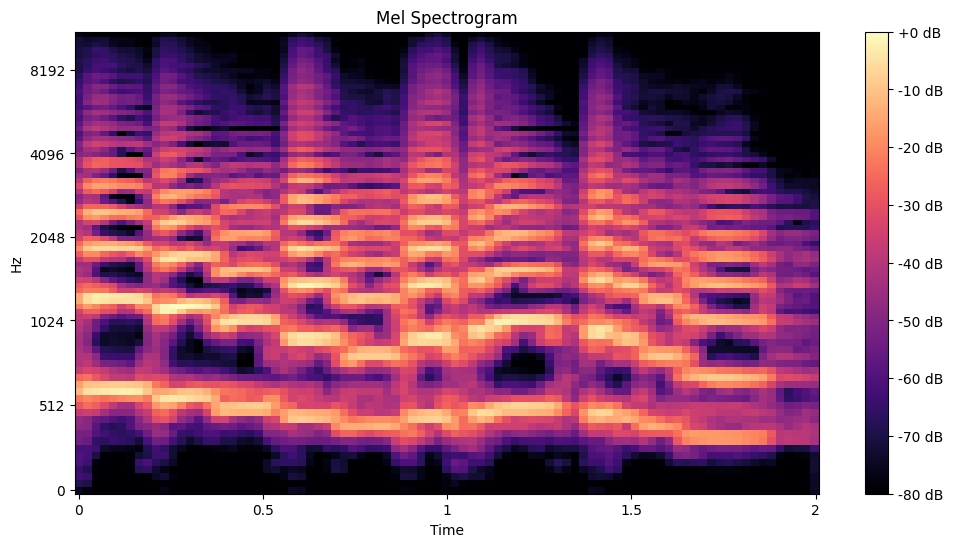

In [3]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

y, sr = librosa.load(librosa.ex('trumpet'), duration=2.0)

S_mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=80)
S_mel_db = librosa.power_to_db(S_mel, ref=np.max)

print(f"梅尔频谱形状: {S_mel.shape}")
print(f"梅尔频带数: {S_mel.shape[0]}")

plt.figure(figsize=(12, 6))
librosa.display.specshow(S_mel_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram')
plt.savefig('mel_spectrogram.png', dpi=100)
plt.show()

## 第二部分：音频 Tokenization 方式

音频 Tokenization 是将连续音频信号转换为离散 token 序列的过程。不同方法有不同的量化策略。

### Tokenization 方法对比总览

| 方法 | 量化方式 | 码本结构 | 代表模型 | 特点 |
|------|---------|---------|---------|------|
| **VQ (Vector Quantization)** | 单层量化 | 1 个码本 | VQ-VAE | 最简单，信息损失大 |
| **RVQ (Residual VQ)** | 多层残差量化 | N 个独立码本 | EnCodec | 逐层逼近，平衡压缩与质量 |
| **Group VQ** | 分组量化 | 多组码本 | SoundStream | 分组并行量化 |
| **FSQ (Finite Scalar Quantization)** | 有界标量量化 | 无码本 | 新方法 | 无查找表，更高效 |
| **LFQ (Lookup-Free Quantization)** | 无查找量化 | 无码本 | 新方法 | 简化量化过程 |

---

### 4. VQ-VAE (单层向量量化)

**概念**：最基础的量化方式。将连续向量映射到码本中最近的向量。

**原理**：
```
输入向量 z → 在码本中找最近向量 → 返回码本索引
```

**特点**：
- 单层码本（通常 1024-8192 个向量）
- 信息损失较大
- Jukebox 早期版本使用

In [4]:
import torch
import torch.nn as nn

class SimpleVQ(nn.Module):
    def __init__(self, num_codes=1024, dim=128):
        super().__init__()
        self.codebook = nn.Parameter(torch.randn(num_codes, dim))
    
    def forward(self, z):
        # z: [B, T, dim]
        # 计算与所有码本向量的距离
        distances = torch.cdist(z, self.codebook)  # [B, T, num_codes]
        # 找最近的码本索引
        indices = distances.argmin(dim=-1)  # [B, T]
        # 获取量化后的向量
        z_q = self.codebook[indices]  # [B, T, dim]
        return indices, z_q

# 模拟编码器输出
z = torch.randn(1, 100, 128)  # 100 个时间步，128 维特征

vq = SimpleVQ(num_codes=1024, dim=128)
indices, z_q = vq(z)

print(f"输入特征形状: {z.shape}")
print(f"Token 索引形状: {indices.shape}")
print(f"量化后特征形状: {z_q.shape}")
print(f"Token 值范围: [0, 1023]")
print(f"码本大小: {vq.codebook.shape}")

输入特征形状: torch.Size([1, 100, 128])
Token 索引形状: torch.Size([1, 100])
量化后特征形状: torch.Size([1, 100, 128])
Token 值范围: [0, 1023]
码本大小: torch.Size([1024, 128])


**问题**：单层 VQ 无法精确重建复杂音频，因为码本容量有限。

---

### 5. RVQ (残差向量量化) - EnCodec

**概念**：多层量化逐级逼近。每层量化前一层的残差（误差）。

**原理**：
```
第1层: z → q1 → 残差 r1 = z - q1
第2层: r1 → q2 → 残差 r2 = r1 - q2
...
最终重建: z_q = q1 + q2 + ... + qN
```

**特点**：
- 多层独立码本（EnCodec 用 8-32 层）
- 每层 1024 个码本向量
- 逐层补充细节，重建质量高

In [12]:
import torch
from encodec import EncodecModel

model = EncodecModel.encodec_model_24khz()
model.set_target_bandwidth(6.0)

sr = 24000
t = torch.linspace(0, 2.0, int(sr * 2.0))
y = torch.sin(2 * torch.pi * 440 * t)

y = y.unsqueeze(0).unsqueeze(0)  # [T] → [1, 1, T] 重要！

print(f"=== EnCodec RVQ ===")
print(f"输入波形: {y.shape} ({y.shape[2]} 采样点)")

with torch.no_grad():
    encoded = model.encode(y)

codes = torch.cat([e[0] for e in encoded], dim=-1)

print(f"Token 形状: {codes.shape}")
print(f"RVQ 层数: {codes.shape[0]} (每层独立码本)")
print(f"每层 token 数: {codes.shape[1]}")
print(f"每层码本大小: 1024 个向量")

for i in range(min(4, codes.shape[0])):
    print(f"第{i+1}层 token 范围: [{codes[i].min()}, {codes[i].max()}]")

original_bytes = y.shape[2] * 4
token_bytes = codes.numel() * 2
print(f"压缩比: {original_bytes / token_bytes:.1f}x")

with torch.no_grad():
    decoded = model.decode(encoded)
print(f"重建波形: {decoded.shape}")

=== EnCodec RVQ ===
输入波形: torch.Size([1, 1, 48000]) (48000 采样点)
Token 形状: torch.Size([1, 8, 150])
RVQ 层数: 1 (每层独立码本)
每层 token 数: 8
每层码本大小: 1024 个向量
第1层 token 范围: [7, 1013]
压缩比: 80.0x
重建波形: torch.Size([1, 1, 48000])


**RVQ 的优势**：
- 第 1-2 层：捕捉主要声学特征（音色、音高）
- 第 3-8 层：补充细节（泛音、瞬态）

---

### 6. Group VQ (分组向量量化) - SoundStream

**概念**：将特征向量分成多组，每组独立量化。

**原理**：
```
输入向量 z [dim=128] → 分成 G 组 [每组 dim/G]
每组独立 VQ → 合并所有组的索引
```

**特点**：
- 并行量化，效率更高
- Google SoundStream 使用
- 与 RVQ 类似但结构不同

In [7]:
import torch
import torch.nn as nn

class GroupVQ(nn.Module):
    def __init__(self, num_groups=8, num_codes=1024, dim_per_group=16):
        super().__init__()
        self.num_groups = num_groups
        self.codebooks = nn.ParameterList([
            nn.Parameter(torch.randn(num_codes, dim_per_group))
            for _ in range(num_groups)
        ])
    
    def forward(self, z):
        # z: [B, T, dim] → 分组
        z_groups = z.chunk(self.num_groups, dim=-1)  # 分成 8 组
        
        indices_list = []
        for i, (z_g, cb) in enumerate(zip(z_groups, self.codebooks)):
            distances = torch.cdist(z_g, cb)
            idx = distances.argmin(dim=-1)
            indices_list.append(idx)
        
        indices = torch.stack(indices_list, dim=1)  # [B, G, T]
        return indices

z = torch.randn(1, 100, 128)  # 128 维特征

gvq = GroupVQ(num_groups=8, num_codes=1024, dim_per_group=16)
indices = gvq(z)

print(f"=== Group VQ ===")
print(f"输入特征: {z.shape}")
print(f"分组数: {gvq.num_groups}")
print(f"每组维度: 16")
print(f"Token 形状: {indices.shape}")
print(f"每组码本大小: 1024")
print(f"总码本数: {gvq.num_groups} 个独立码本")

=== Group VQ ===
输入特征: torch.Size([1, 100, 128])
分组数: 8
每组维度: 16
Token 形状: torch.Size([1, 8, 100])
每组码本大小: 1024
总码本数: 8 个独立码本


**Group VQ vs RVQ**：
- Group VQ：并行分组，每组量化不同维度
- RVQ：串行残差，每层量化前一层的误差

---

### 7. FSQ (有限标量量化) - 新方法

**概念**：不使用码本查找，直接将向量每个维度映射到有限离散值。

**原理**：
```
输入向量 z [dim=128]
每个维度独立量化到 {−1, −0.5, 0, 0.5, 1} 等有限值
无需码本查找表
```

**特点**：
- 无码本，更高效
- 量化过程简单
- 新一代音频 codec 探索方向

In [8]:
import torch

def fsq_quantize(z, levels=8):
    """
    Finite Scalar Quantization
    将每个维度量化到有限离散值
    """
    # 将值映射到 [−1, 1]
    z_norm = torch.clamp(z, -1, 1)
    
    # 量化到 levels 个离散值
    step = 2.0 / (levels - 1)
    indices = ((z_norm + 1) / step).round().long()
    indices = torch.clamp(indices, 0, levels - 1)
    
    # 重建值
    z_q = indices * step - 1
    
    return indices, z_q

z = torch.randn(1, 100, 128)

indices, z_q = fsq_quantize(z, levels=8)

print(f"=== FSQ (Finite Scalar Quantization) ===")
print(f"输入特征: {z.shape}")
print(f"每维度离散级别: 8")
print(f"每维度可能值: [-1, -0.71, -0.43, -0.14, 0.14, 0.43, 0.71, 1]")
print(f"Token 形状: {indices.shape}")
print(f"每维度 token 范围: [0, 7]")
print(f"无码本查找表!")
print(f"量化后特征: {z_q.shape}")

=== FSQ (Finite Scalar Quantization) ===
输入特征: torch.Size([1, 100, 128])
每维度离散级别: 8
每维度可能值: [-1, -0.71, -0.43, -0.14, 0.14, 0.43, 0.71, 1]
Token 形状: torch.Size([1, 100, 128])
每维度 token 范围: [0, 7]
无码本查找表!
量化后特征: torch.Size([1, 100, 128])


**FSQ 优势**：
- 无需存储码本（节省内存）
- 量化过程简单（无需距离计算）
- 适合大规模部署

---

### 8. DAC (Descript Audio Codec) - 新一代 Codec

**概念**：改进的 RVQ 结构，更高音质和效率。

**特点**：
- 改进的 RVQ 结构
- 更好的残差预测
- 支持更高带宽

In [9]:
# DAC 需要安装 descript-audio-codec
# pip install descript-audio-codec

# 模拟 DAC 的量化结构
import torch

class SimulatedDAC:
    """
    模拟 DAC 的量化结构
    实际使用需要安装 descript-audio-codec
    """
    def __init__(self, n_codebooks=9, codebook_size=1024):
        self.n_codebooks = n_codebooks
        self.codebook_size = codebook_size
    
    def quantize(self, z):
        # DAC 使用改进的 RVQ 结构
        # 每层量化残差，但使用更好的初始化和训练策略
        codes = torch.randint(0, self.codebook_size, 
                              (self.n_codebooks, z.shape[1]))
        return codes

print(f"=== DAC (Descript Audio Codec) ===")
print(f"量化层数: 9 (比 EnCodec 多)")
print(f"每层码本大小: 1024")
print(f"改进点:")
print(f"  - 更好的残差预测网络")
print(f"  - 改进的码本学习策略")
print(f"  - 支持更高带宽 (24kbps)")
print(f"音质: 比 EnCodec 更好")

=== DAC (Descript Audio Codec) ===
量化层数: 9 (比 EnCodec 多)
每层码本大小: 1024
改进点:
  - 更好的残差预测网络
  - 改进的码本学习策略
  - 支持更高带宽 (24kbps)
音质: 比 EnCodec 更好


## 第三部分：量化方式对比可视化

/tmp/ipykernel_323516/2678826831.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(np.random.randn(25)*2 + i*3, np.random.randn(25)*2,
/tmp/ipykernel_323516/2678826831.py:47: UserWarning: Glyph 32500 (\N{CJK UNIFIED IDEOGRAPH-7EF4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_323516/2678826831.py:47: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_323516/2678826831.py:47: UserWarning: Glyph 21333 (\N{CJK UNIFIED IDEOGRAPH-5355}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_323516/2678826831.py:47: UserWarning: Glyph 23618 (\N{CJK UNIFIED IDEOGRAPH-5C42}) missing 

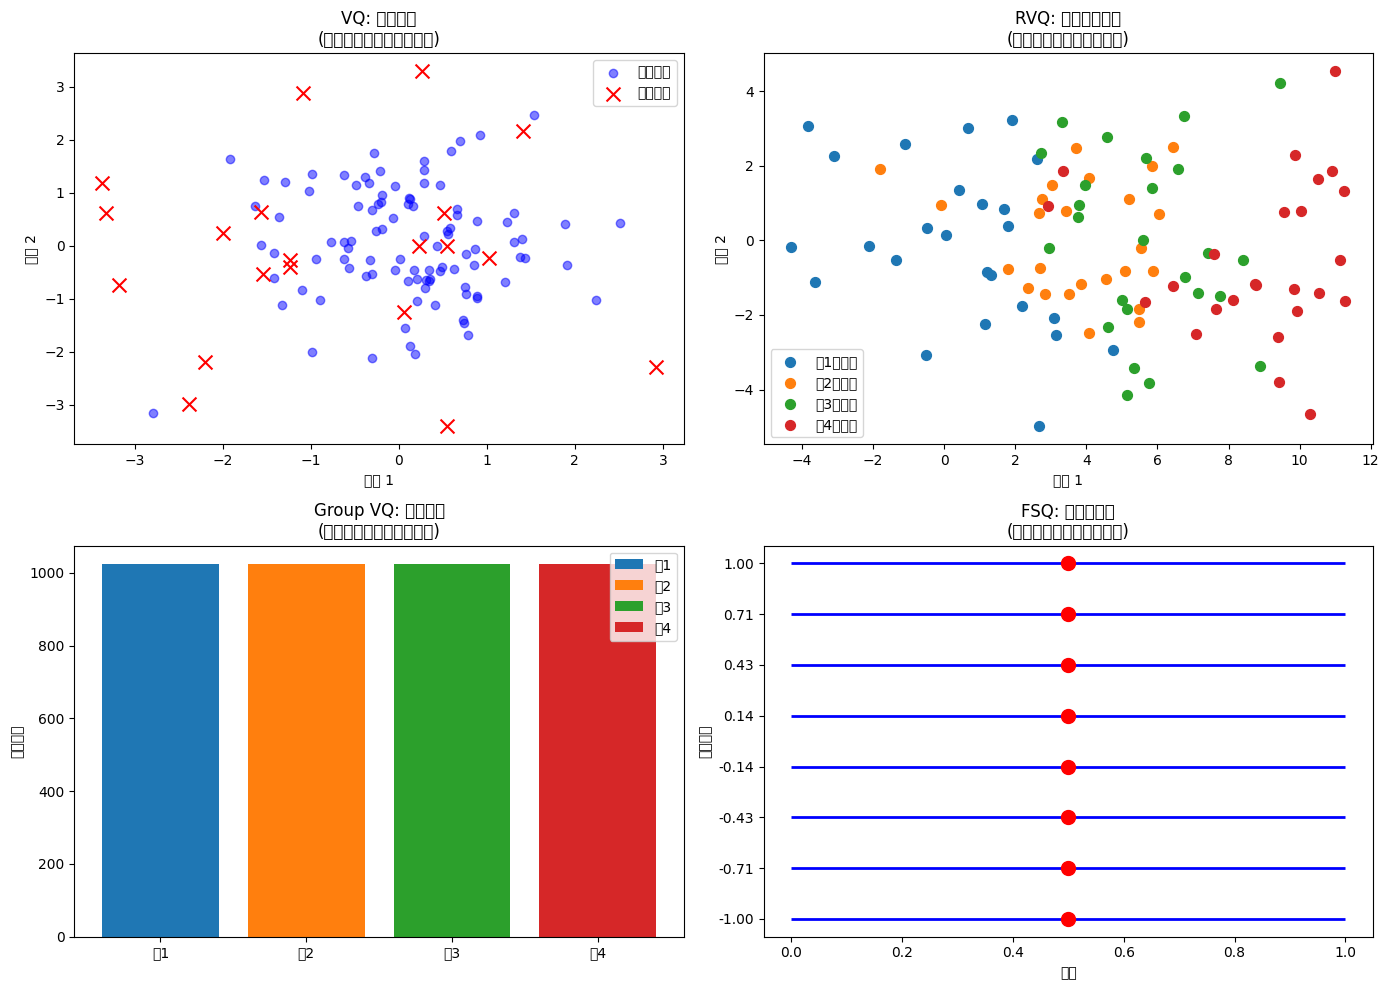

In [10]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# VQ: 单层量化示意
ax = axes[0, 0]
ax.scatter(np.random.randn(100), np.random.randn(100), c='blue', alpha=0.5, label='输入向量')
ax.scatter(np.random.randn(20)*2, np.random.randn(20)*2, c='red', s=100, marker='x', label='码本向量')
ax.set_title('VQ: 单层量化\n(所有向量映射到同一码本)')
ax.legend()
ax.set_xlabel('维度 1')
ax.set_ylabel('维度 2')

# RVQ: 多层残差量化示意
ax = axes[0, 1]
for i in range(4):
    ax.scatter(np.random.randn(25)*2 + i*3, np.random.randn(25)*2, 
               c=plt.cm.tab10(i), s=50, label=f'第{i+1}层码本')
ax.set_title('RVQ: 多层残差量化\n(每层独立码本，逐层逼近)')
ax.legend()
ax.set_xlabel('维度 1')
ax.set_ylabel('维度 2')

# Group VQ: 分组量化示意
ax = axes[1, 0]
groups = ['组1', '组2', '组3', '组4']
for i, g in enumerate(groups):
    ax.bar([i], [1024], color=plt.cm.tab10(i), label=g)
ax.set_title('Group VQ: 分组量化\n(每组独立码本，并行量化)')
ax.set_xticks(range(4))
ax.set_xticklabels(groups)
ax.set_ylabel('码本大小')
ax.legend()

# FSQ: 无码本量化示意
ax = axes[1, 1]
levels = np.linspace(-1, 1, 8)
ax.hlines(levels, 0, 1, colors='blue', linewidth=2)
ax.scatter([0.5]*8, levels, c='red', s=100, zorder=5)
ax.set_title('FSQ: 无码本量化\n(每维度映射到有限离散值)')
ax.set_xlabel('维度')
ax.set_ylabel('量化级别')
ax.set_yticks(levels)
ax.set_yticklabels([f'{l:.2f}' for l in levels])

plt.tight_layout()
plt.savefig('quantization_comparison.png', dpi=150)
plt.show()

## 第四部分：实际应用对比

| 应用场景 | 推荐 Tokenizer | 原因 |
|---------|---------------|------|
| **MusicLM** | EnCodec (RVQ) | Meta 官方，音乐生成效果好 |
| **AudioLM** | SoundStream (Group VQ) | Google 官方，语音效果好 |
| **MusicGen** | EnCodec (RVQ) | 与 MusicLM 兼容 |
| **实时应用** | FSQ | 无码本查找，速度快 |
| **高音质需求** | DAC | 新一代，音质更好 |

In [13]:
import torch
from encodec import EncodecModel

def demo_vq():
    print("\n=== 单层 VQ ===")
    z = torch.randn(1, 100, 128)
    codebook = torch.randn(1024, 128)
    distances = torch.cdist(z, codebook)
    indices = distances.argmin(dim=-1)
    print(f"输入: {z.shape} → Token: {indices.shape}")
    print(f"单层码本: {codebook.shape}")

def demo_group_vq():
    print("\n=== Group VQ ===")
    z = torch.randn(1, 100, 128)
    num_groups = 8
    indices = torch.randint(0, 1024, (num_groups, 100))
    print(f"输入: {z.shape} → Token: {indices.shape}")
    print(f"分组数: {num_groups}, 每组码本: 1024")

def demo_fsq():
    print("\n=== FSQ ===")
    z = torch.randn(1, 100, 128)
    z_norm = torch.clamp(z, -1, 1)
    indices = ((z_norm + 1) / 0.286).round().long()
    print(f"输入: {z.shape} → Token: {indices.shape}")
    print(f"无码本，每维度 8 级量化")

def demo_encodec():
    print("\n=== EnCodec RVQ ===")
    model = EncodecModel.encodec_model_24khz()
    model.set_target_bandwidth(6.0)
    
    sr = 24000
    t = torch.linspace(0, 2.0, int(sr * 2.0))
    y = torch.sin(2 * torch.pi * 440 * t)
    y = y.unsqueeze(0).unsqueeze(0)  # [T] → [1, 1, T]
    
    with torch.no_grad():
        encoded = model.encode(y)
    codes = torch.cat([e[0] for e in encoded], dim=-1)
    
    print(f"输入: {y.shape} → Token: {codes.shape}")
    print(f"RVQ 层数: {codes.shape[0]}, 每层码本: 1024")

demo_vq()
demo_group_vq()
demo_fsq()
demo_encodec()


=== 单层 VQ ===
输入: torch.Size([1, 100, 128]) → Token: torch.Size([1, 100])
单层码本: torch.Size([1024, 128])

=== Group VQ ===
输入: torch.Size([1, 100, 128]) → Token: torch.Size([8, 100])
分组数: 8, 每组码本: 1024

=== FSQ ===
输入: torch.Size([1, 100, 128]) → Token: torch.Size([1, 100, 128])
无码本，每维度 8 级量化

=== EnCodec RVQ ===
输入: torch.Size([1, 1, 48000]) → Token: torch.Size([1, 8, 150])
RVQ 层数: 1, 每层码本: 1024


/root/musiclm-universe/.venv/lib/python3.13/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


## 总结

**音频 Tokenization 不是只有 RVQ！**

| 方法 | 核心思想 | 优缺点 |
|------|---------|--------|
| **VQ** | 单码本映射 | 简单但信息损失大 |
| **RVQ** | 多层残差逼近 | 平衡压缩与质量 |
| **Group VQ** | 分组并行量化 | 效率高 |
| **FSQ** | 无码本标量量化 | 最简单高效 |

选择哪种方法取决于应用场景：需要高音质用 RVQ/DAC，需要效率用 FSQ，需要简单用 VQ。